Dataset shape: (395, 33)
Gözlem sayısı: 395, Değişken sayısı: 33

İlk 5 satır:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

VERİ TAN

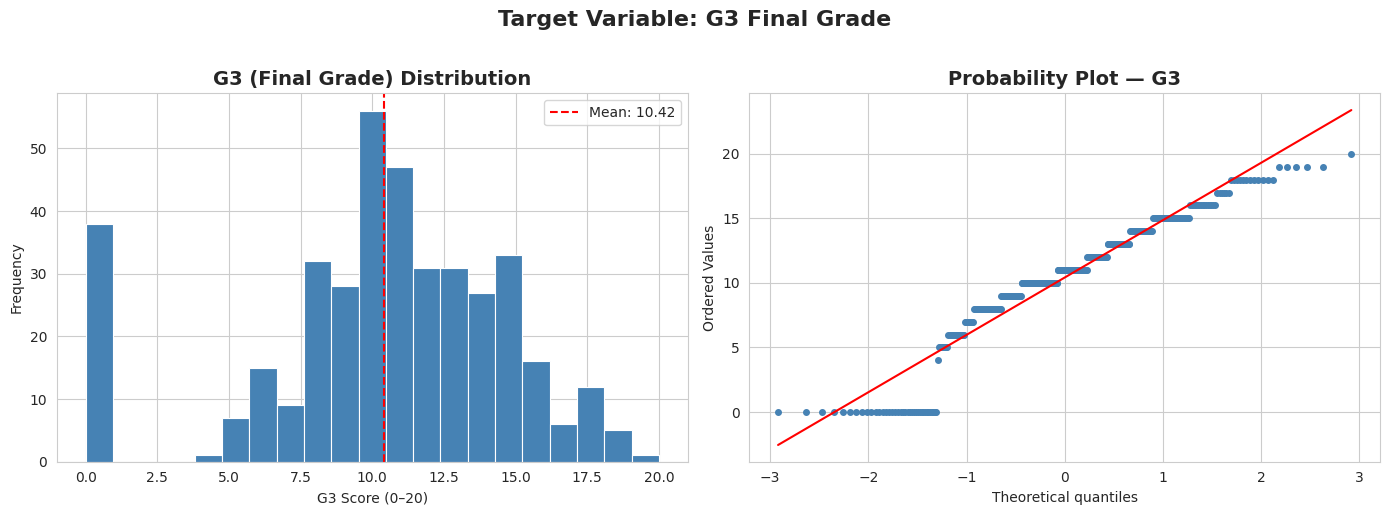


G3 Descriptive Stats:
count    395.000
mean      10.415
std        4.581
min        0.000
25%        8.000
50%       11.000
75%       14.000
max       20.000
Name: G3, dtype: float64
Skewness : -0.733
Kurtosis : 0.403

Not: G3=0 olan öğrenci sayısı: 38 (%9.6) — muhtemelen devamsızlık/bırakma


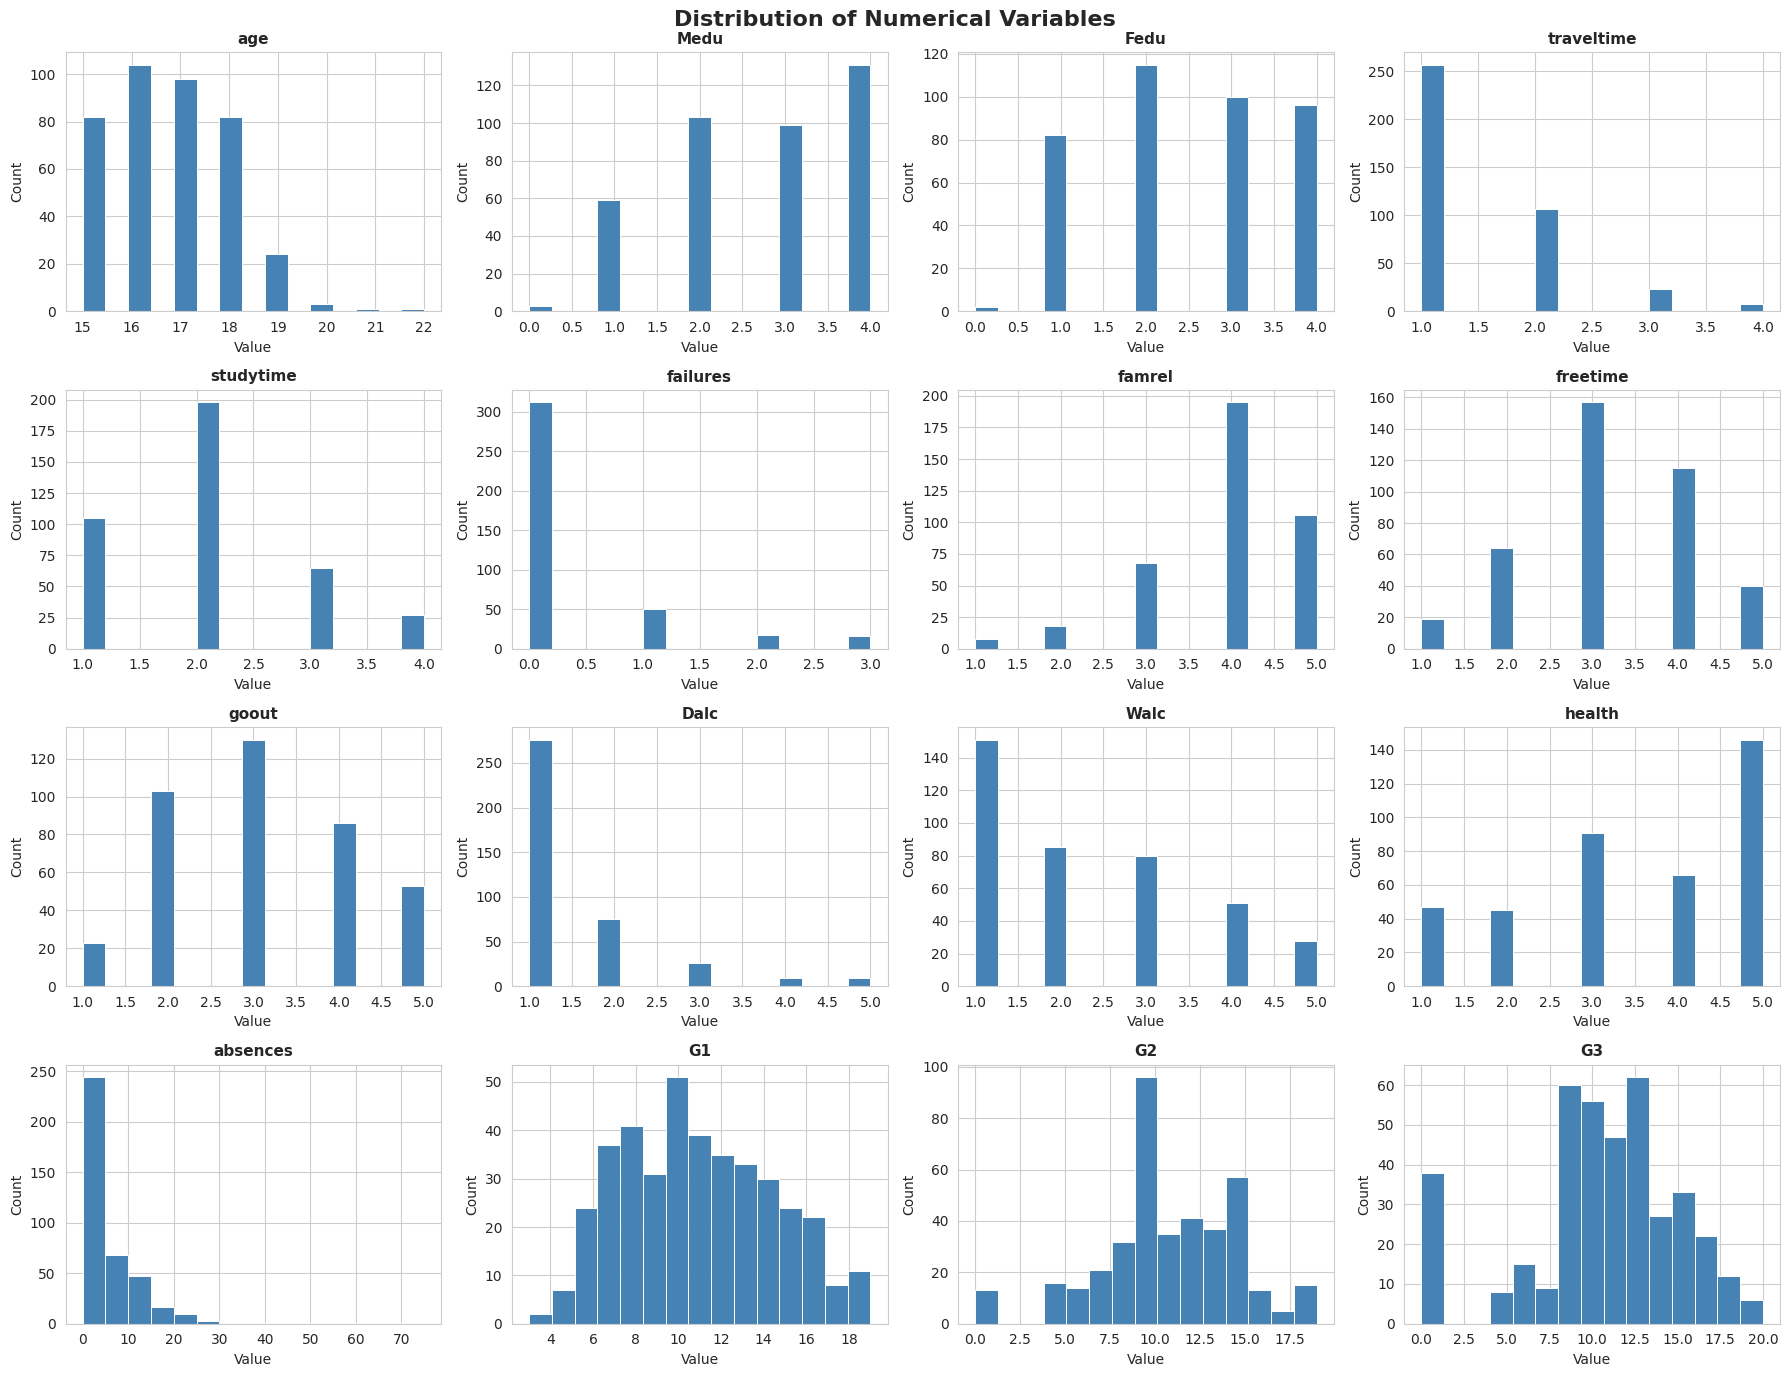

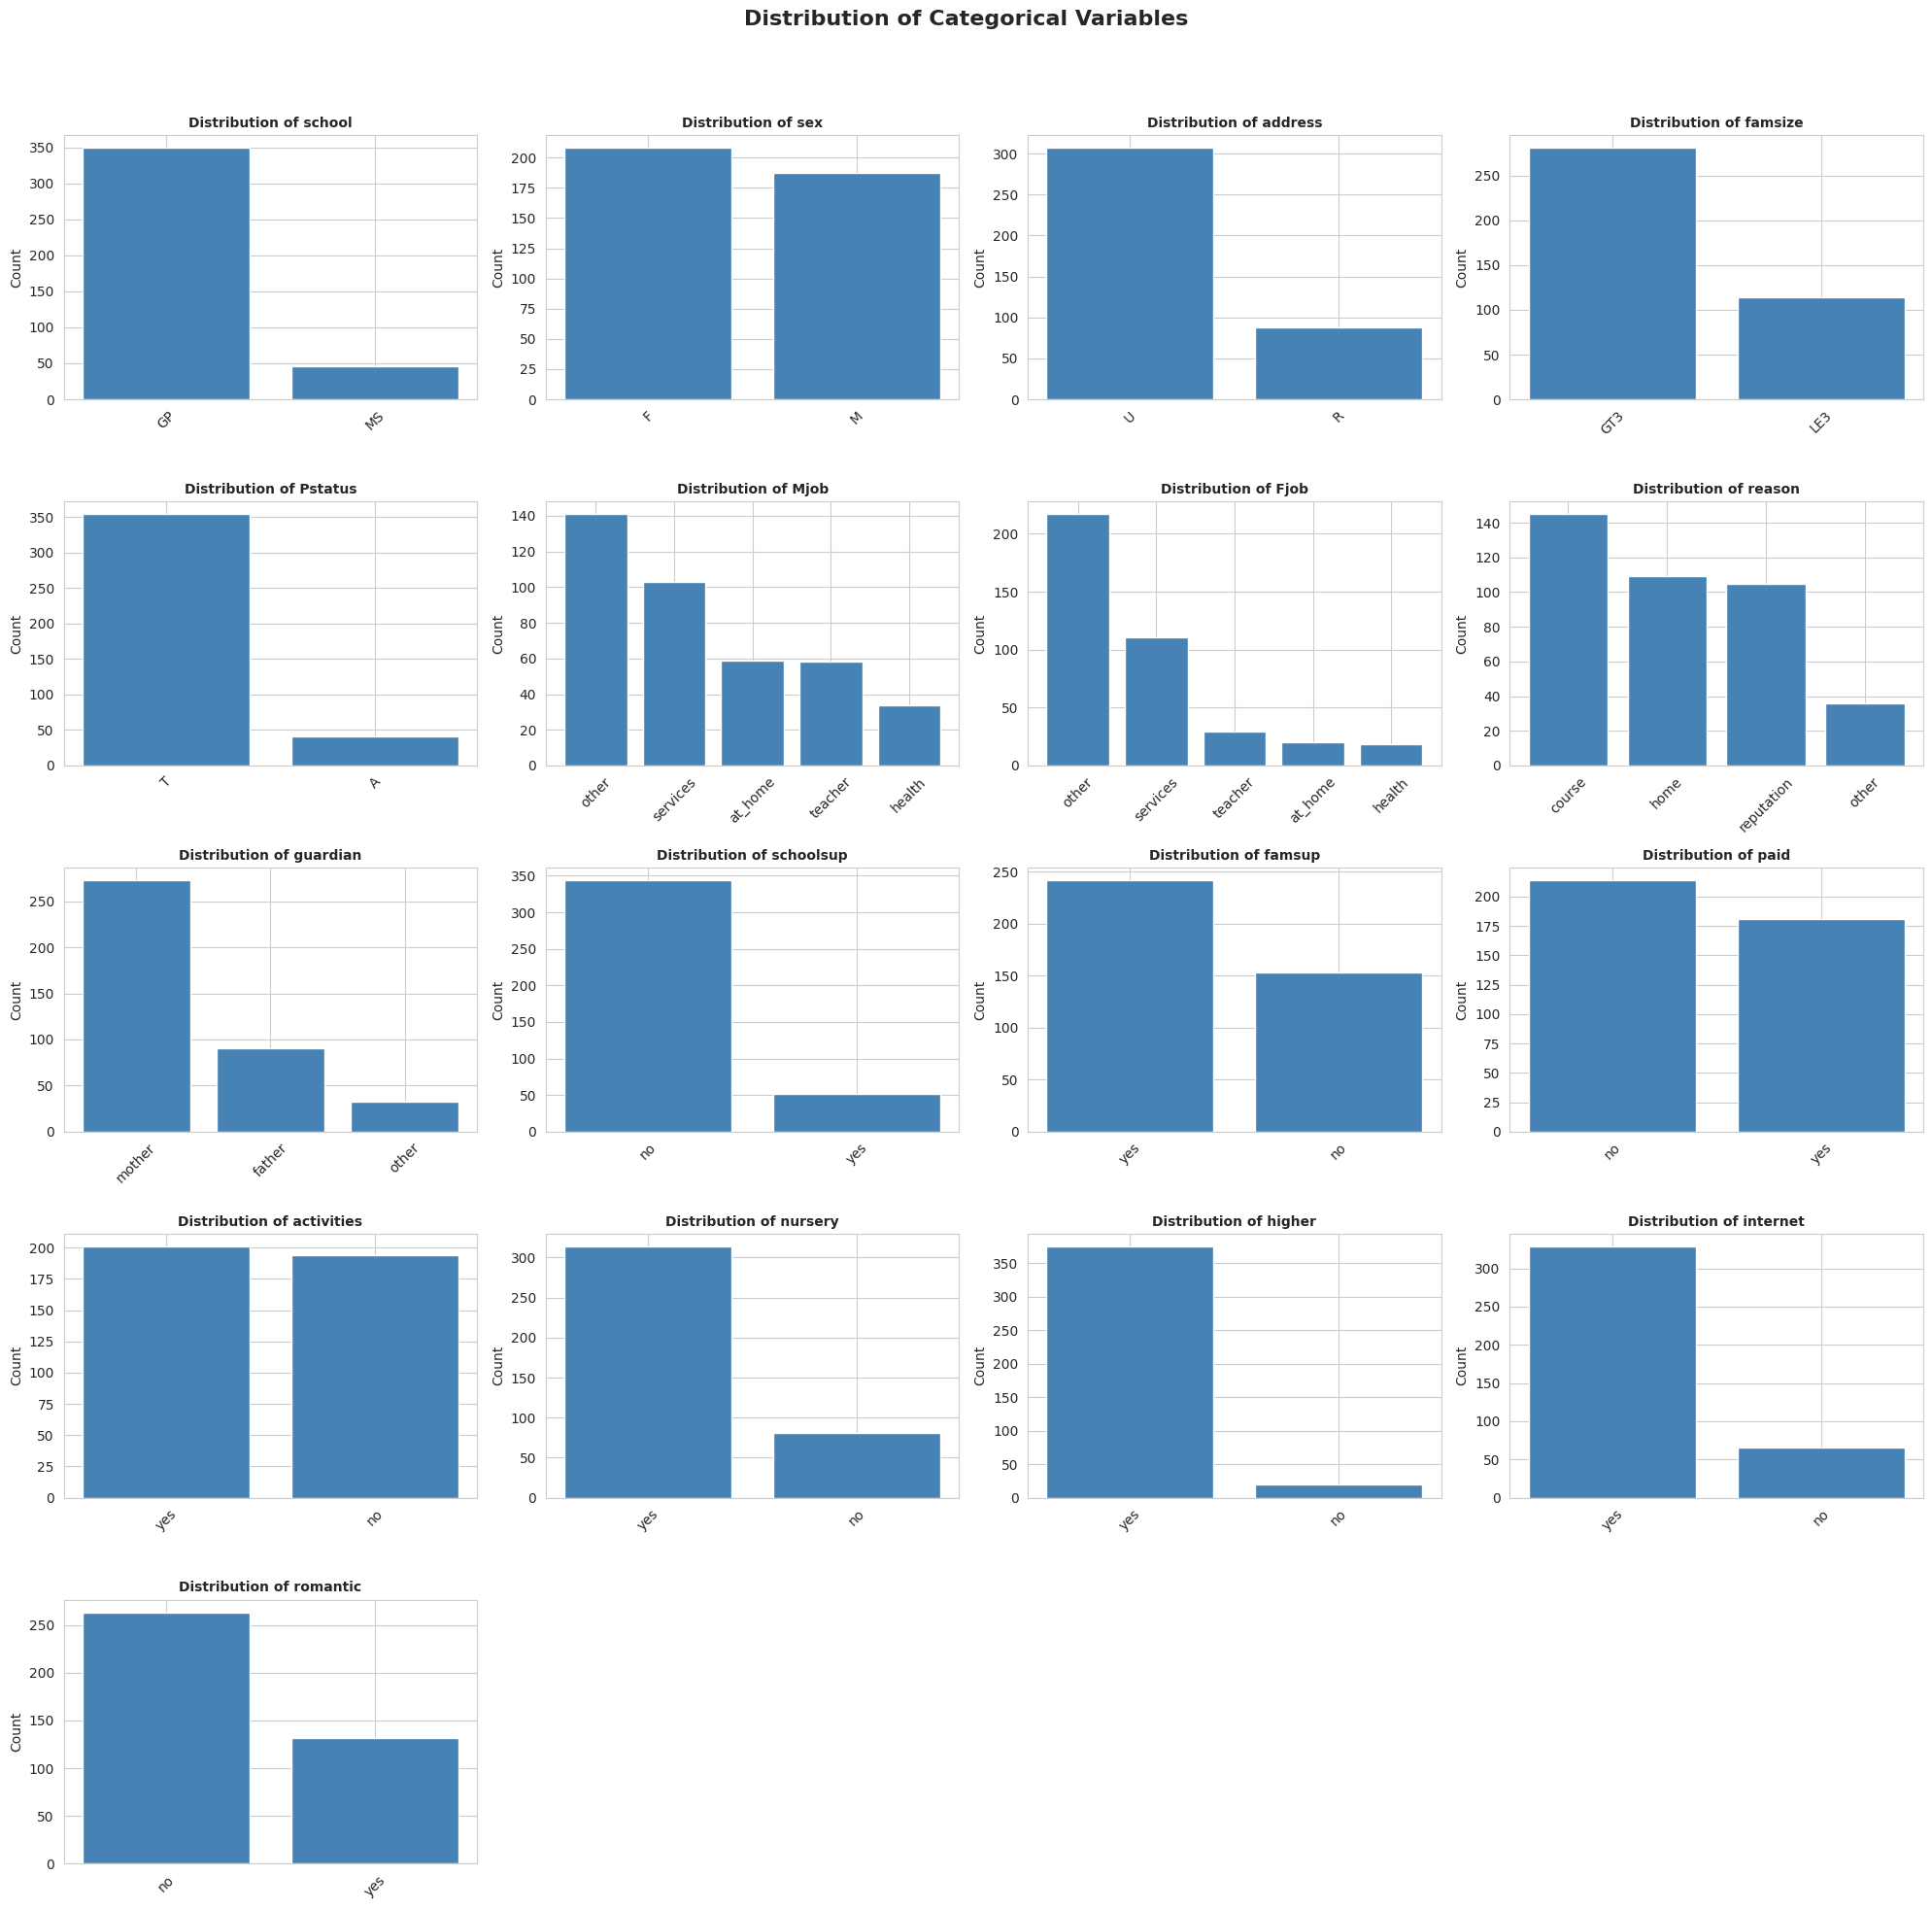

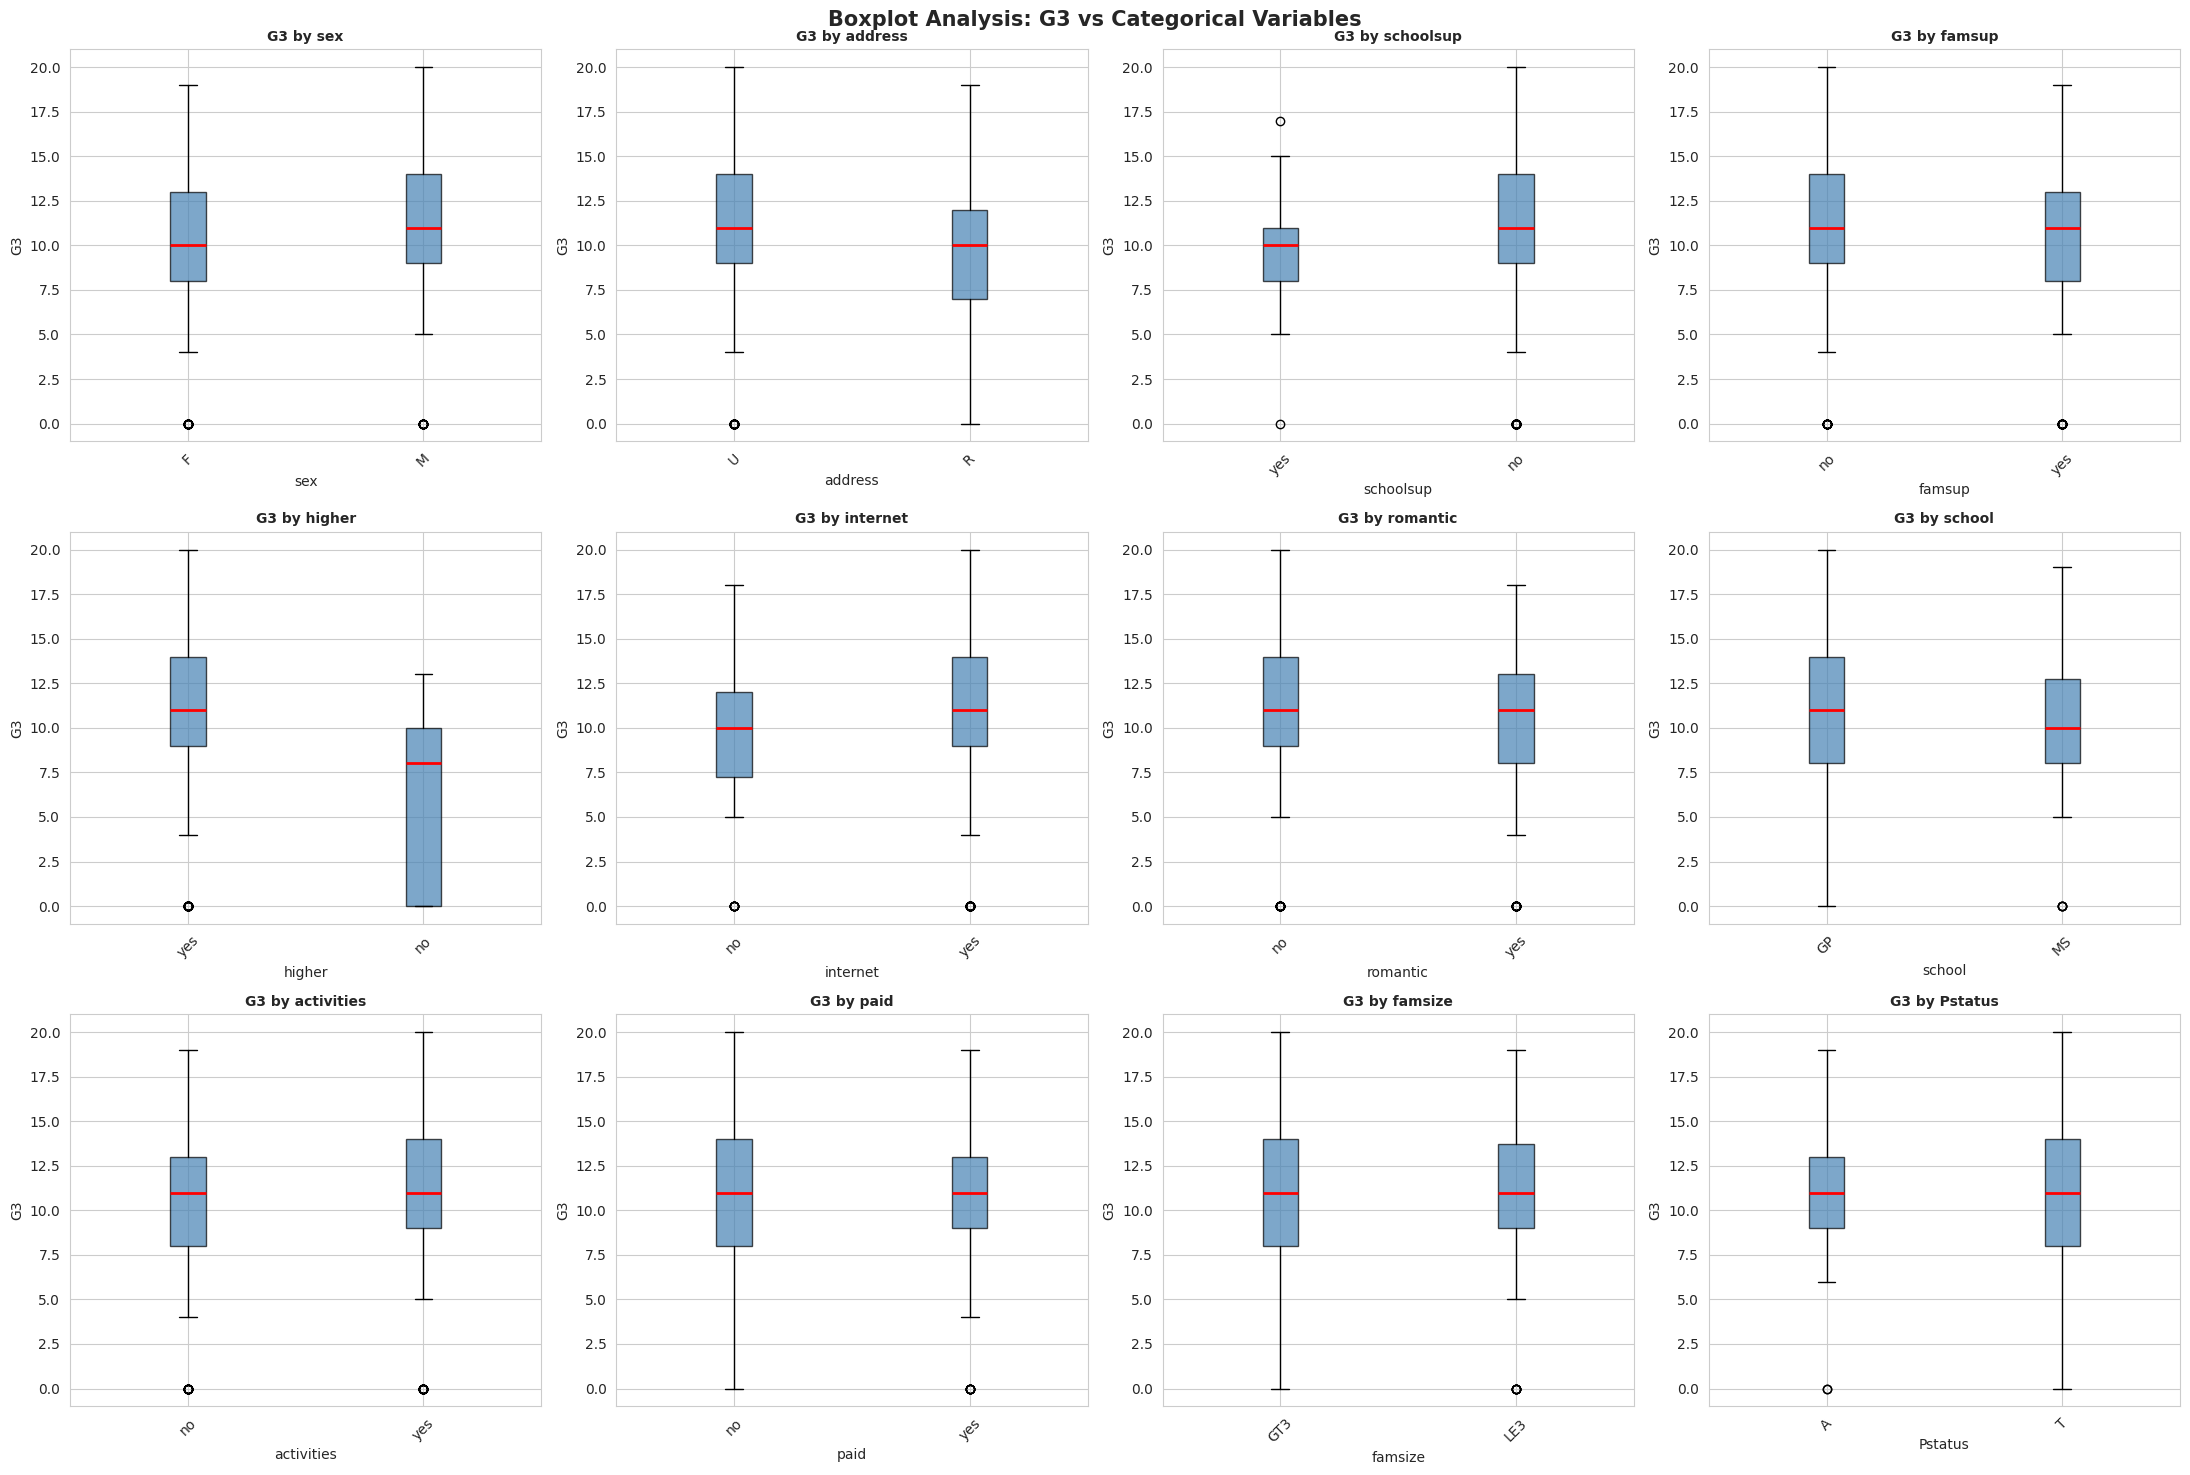


Median G3 by sex:
sex
F    10.0
M    11.0
Name: G3, dtype: float64

Median G3 by higher:
higher
no      8.0
yes    11.0
Name: G3, dtype: float64

Median G3 by internet:
internet
no     10.0
yes    11.0
Name: G3, dtype: float64

Median G3 by address:
address
R    10.0
U    11.0
Name: G3, dtype: float64

Median G3 by schoolsup:
schoolsup
no     11.0
yes    10.0
Name: G3, dtype: float64


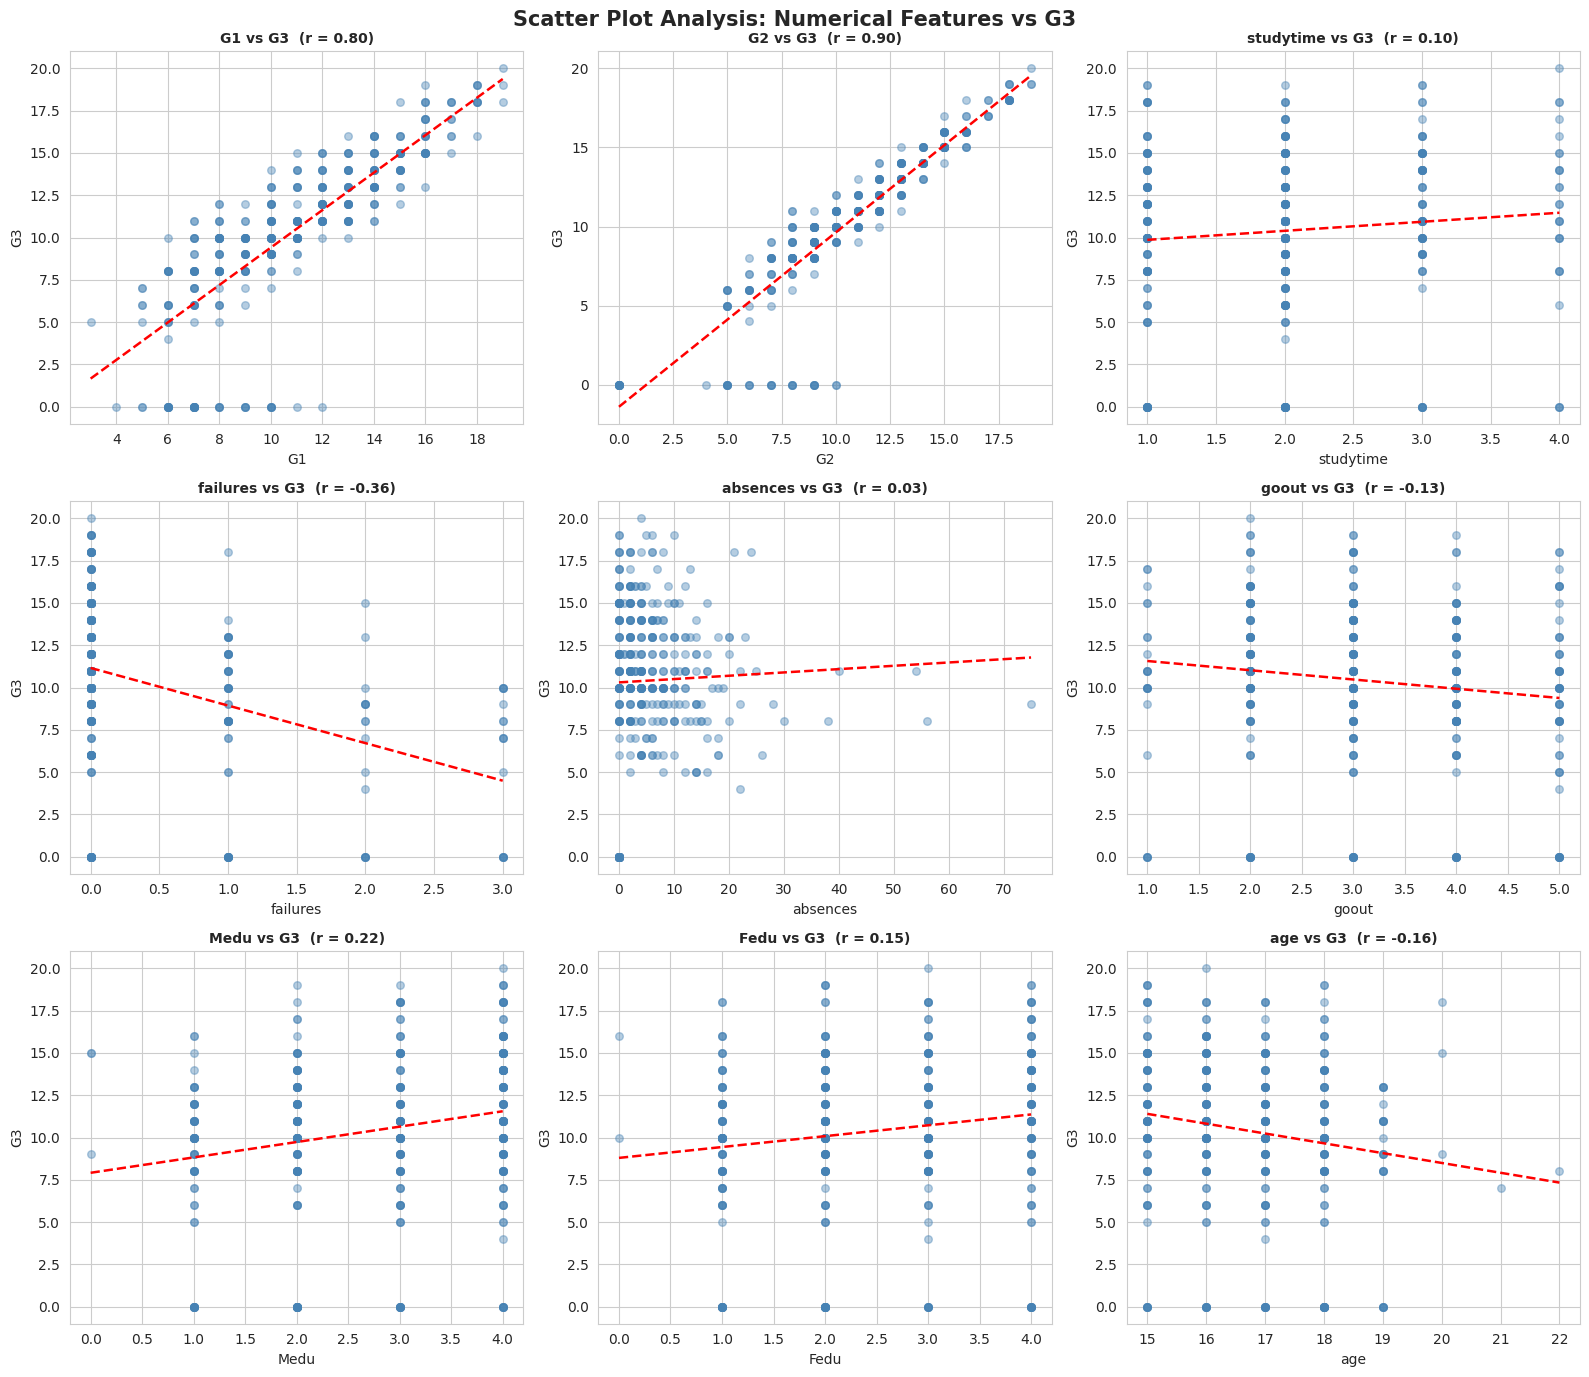

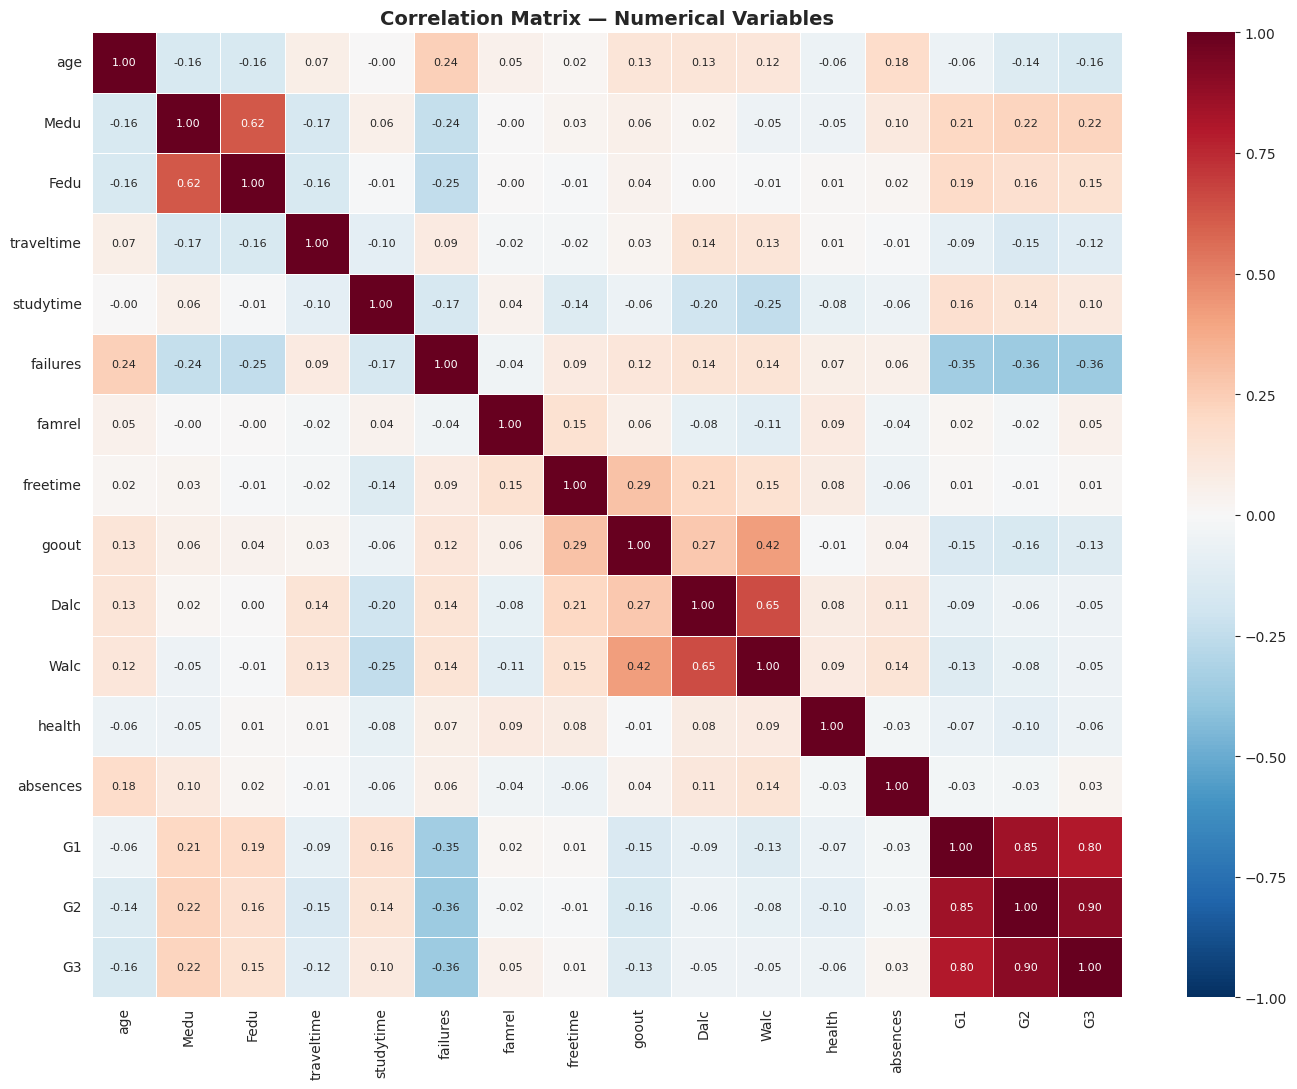


G3 ile Korelasyonlar (büyükten küçüğe):
G2            0.90
G1            0.80
failures      0.36
Medu          0.22
age           0.16
Fedu          0.15
goout         0.13
traveltime    0.12
studytime     0.10
health        0.06
famrel        0.05
Dalc          0.05
Walc          0.05
absences      0.03
freetime      0.01
Name: G3, dtype: float64


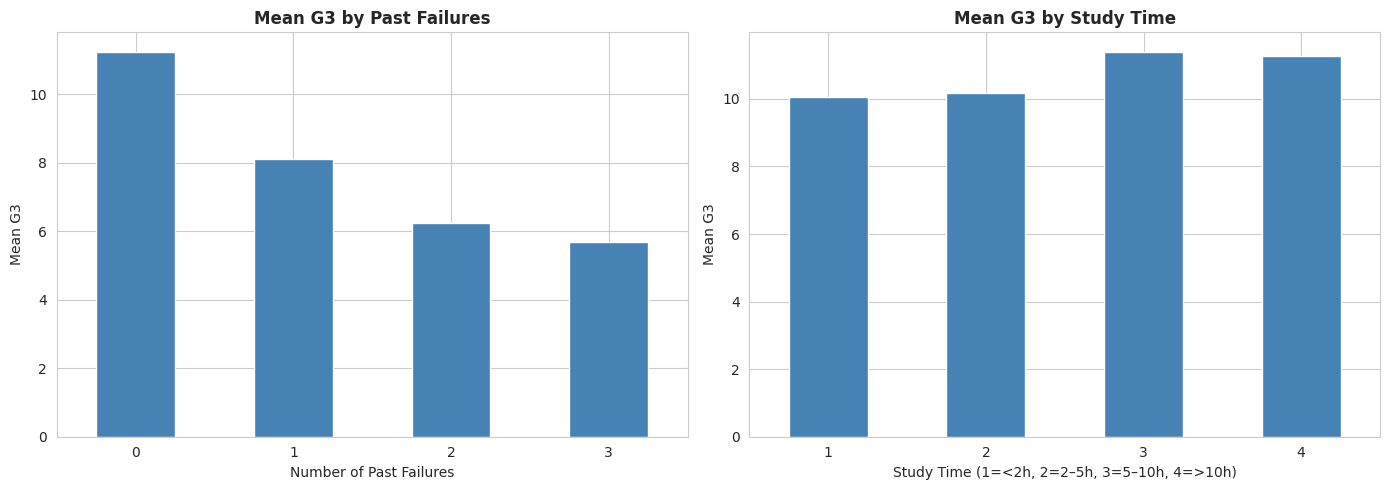


✅ EDA tamamlandı!
Çıktılar: 01–07 numaralı PNG dosyaları olarak kaydedildi.

Sıradaki adım: Preprocessing + Model Training (Part 2)


In [ ]:
# ================================================================
# STUDENT PERFORMANCE PREDICTION
# UCI Student Performance Dataset — student-mat.csv
# Kaynak: Cortez & Silva, 2008
# Hedef Değişken: G3 — Final Grade (0–20)
# ================================================================

# ── 0. KÜTÜPHANELER ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
sns.set_palette("Blues_r")

# ── 1. VERİ YÜKLEME ──────────────────────────────────────────────
url = "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv"
df = pd.read_csv(url, sep=';')

print("Dataset shape:", df.shape)
print(f"Gözlem sayısı: {df.shape[0]}, Değişken sayısı: {df.shape[1]}")
print("\nİlk 5 satır:")
print(df.head())

# ── 2. VERİ TANIMI ───────────────────────────────────────────────
print("\n" + "="*60)
print("VERİ TANIMI (df.info)")
print("="*60)
print(df.info())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"\nKategorik değişkenler ({len(cat_cols)}): {cat_cols}")
print(f"Sayısal değişkenler  ({len(num_cols)}): {num_cols}")

# ── 3. MISSING VALUE CHECK ──────────────────────────────────────
print("\n" + "="*60)
print("MISSING VALUE CHECK")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing value: {missing.sum()}")

# ── 4. TANIMLAYICI İSTATİSTİKLER ────────────────────────────────
print("\n" + "="*60)
print("TANIMLAYICI İSTATİSTİKLER")
print("="*60)
print(df[num_cols].describe().round(2))

# ── 5. TARGET VARIABLE (G3) DISTRIBUTION ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['G3'], bins=21, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].set_title('G3 (Final Grade) Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('G3 Score (0–20)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['G3'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['G3'].mean():.2f}")
axes[0].legend()

stats.probplot(df['G3'], plot=axes[1])
axes[1].set_title('Probability Plot — G3', fontsize=14, fontweight='bold')
axes[1].get_lines()[0].set(color='steelblue', markersize=4)
axes[1].get_lines()[1].set(color='red')

plt.suptitle('Target Variable: G3 Final Grade', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_G3_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nG3 Descriptive Stats:")
print(df['G3'].describe().round(3))
print(f"Skewness : {df['G3'].skew():.3f}")
print(f"Kurtosis : {df['G3'].kurtosis():.3f}")
print(f"\nNot: G3=0 olan öğrenci sayısı: {(df['G3']==0).sum()} "
      f"(%{(df['G3']==0).mean()*100:.1f}) — muhtemelen devamsızlık/bırakma")

# ── 6. SAYISAL DEĞİŞKENLERİN DAĞILIMI ───────────────────────────
num_plot_cols = ['age','Medu','Fedu','traveltime','studytime',
                 'failures','famrel','freetime','goout',
                 'Dalc','Walc','health','absences','G1','G2','G3']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_plot_cols):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='white', linewidth=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. KATEGORİK DEĞİŞKENLERİN DAĞILIMI ─────────────────────────
# Calculate the number of rows needed for subplots
num_cat_cols = len(cat_cols)
num_cols_per_row = 4
num_rows = (num_cat_cols + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(20, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')


for j in range(num_cat_cols, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # üstten %5 boşluk bırakır
plt.savefig('03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. BOXPLOT ANALİZİ — KATEGORİK vs G3 ────────────────────────
key_cat = ['sex', 'address', 'schoolsup', 'famsup',
           'higher', 'internet', 'romantic', 'school',
           'activities', 'paid', 'famsize', 'Pstatus']

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    groups = [df[df[col] == val]['G3'].values for val in df[col].unique()]
    labels  = df[col].unique().tolist()
    bp = axes[i].boxplot(groups, labels=labels, patch_artist=True,
                         medianprops=dict(color='red', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    axes[i].set_title(f'G3 by {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('G3')
    axes[i].tick_params(axis='x', rotation=45) # Increased rotation for better readability

plt.suptitle('Boxplot Analysis: G3 vs Categorical Variables',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_boxplots_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Medyan özeti
for col in ['sex', 'higher', 'internet', 'address', 'schoolsup']:
    print(f"\nMedian G3 by {col}:")
    print(df.groupby(col)['G3'].median())

# ── 9. SCATTER PLOT ANALİZİ — SAYISAL vs G3 ─────────────────────
key_scatter = ['G1', 'G2', 'studytime', 'failures',
               'absences', 'goout', 'Medu', 'Fedu', 'age']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(key_scatter):
    axes[i].scatter(df[col], df['G3'], alpha=0.4, color='steelblue', s=30)
    z = np.polyfit(df[col], df['G3'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.8, linestyle='--')
    r, _ = stats.pearsonr(df[col], df['G3'])
    axes[i].set_title(f'{col} vs G3  (r = {r:.2f})',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('G3')

plt.suptitle('Scatter Plot Analysis: Numerical Features vs G3',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. KORELASYON MATRİSİ ───────────────────────────────────────
corr_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
             'famrel','freetime','goout','Dalc','Walc','health',
             'absences','G1','G2','G3']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numerical Variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nG3 ile Korelasyonlar (büyükten küçüğe):")
print(corr_matrix['G3'].drop('G3').abs().sort_values(ascending=False))

# ── 11. FAILURES & STUDYTIME — ORTALAMA G3 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('failures')['G3'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mean G3 by Past Failures', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Past Failures')
axes[0].set_ylabel('Mean G3')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('studytime')['G3'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean G3 by Study Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Study Time (1=<2h, 2=2–5h, 3=5–10h, 4=>10h)')
axes[1].set_ylabel('Mean G3')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('07_failures_studytime.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ EDA tamamlandı!")
print("Çıktılar: 01–07 numaralı PNG dosyaları olarak kaydedildi.")
print("\nSıradaki adım: Preprocessing + Model Training (Part 2)")

### 12. G3=0 Olan Öğrencilerin Çıkarılması

Daha önceki analizlerde G3 notu 0 olan öğrencilerin muhtemelen devamsızlık nedeniyle veya okulu bırakma gibi sebeplerle bu notu aldığını belirttik. Bu öğrencileri veri setinden çıkarmak, modelimizin gerçek akademik performansı daha doğru bir şekilde tahmin etmesine yardımcı olacaktır. Bu, `df` veri çerçevemizi güncelleyecek ve `G3` değeri 0'dan büyük olan öğrencileri içerecektir.

In [ ]:
# G3 notu 0 olan öğrencileri veri setinden çıkar
df_filtered = df[df['G3'] > 0].copy()

print(f"Orijinal veri seti boyutu: {df.shape[0]} satır")
print(f"G3 notu 0'dan büyük olan öğrenci sayısı: {df_filtered.shape[0]} satır")
print(f"Çıkarılan öğrenci sayısı: {df.shape[0] - df_filtered.shape[0]} satır")

df = df_filtered.copy()

# G3 dağılımını tekrar kontrol et
print("\nGüncel G3 Dağılımı:")
print(df['G3'].describe().round(3))

Orijinal veri seti boyutu: 395 satır
G3 notu 0'dan büyük olan öğrenci sayısı: 357 satır
Çıkarılan öğrenci sayısı: 38 satır

Güncel G3 Dağılımı:
count    357.000
mean      11.524
std        3.228
min        4.000
25%        9.000
50%       11.000
75%       14.000
max       20.000
Name: G3, dtype: float64


Veri seti boyutu: (357, 33)
G3 aralığı: 4 – 20

Label Encoding uygulanacak sütunlar (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Encoding sonrası ilk 3 satır:
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         6   5   6   6  
1       5         3      3     1     1       3         4   5   5   6  
2       4         3      2     2     3       3        10   7   8  10  

[3 rows x 33 columns]

X shape: (357, 32)
y shape: (357,)
Kullanılan özellikler (32):
['school', '

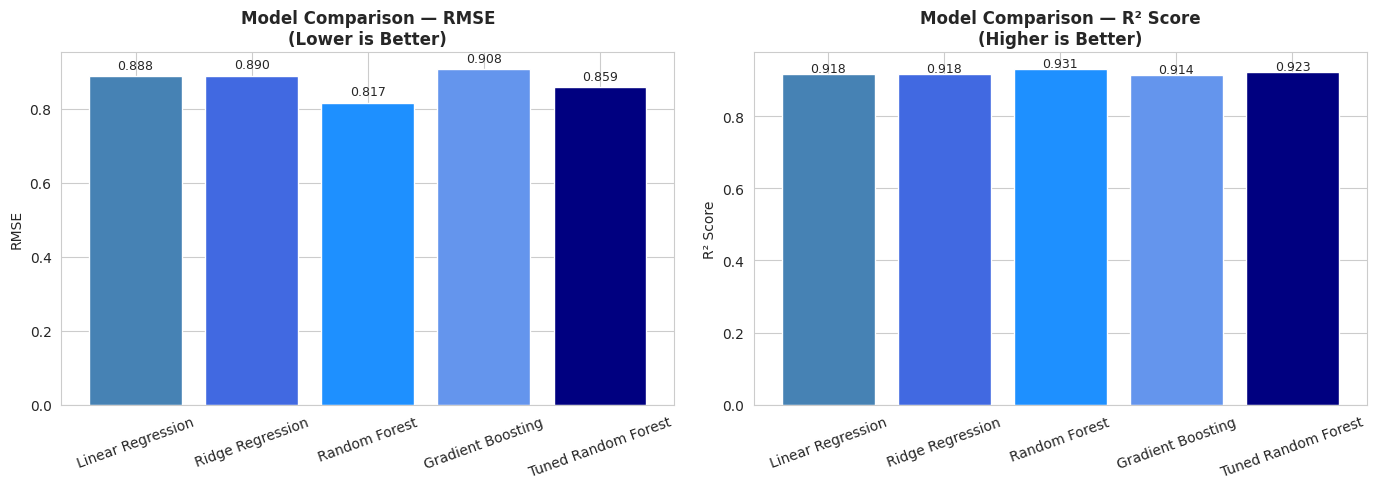

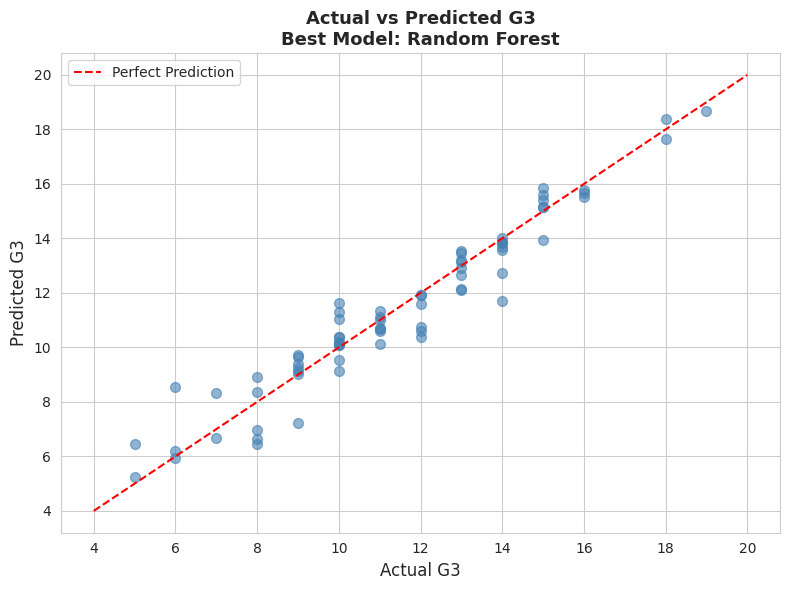

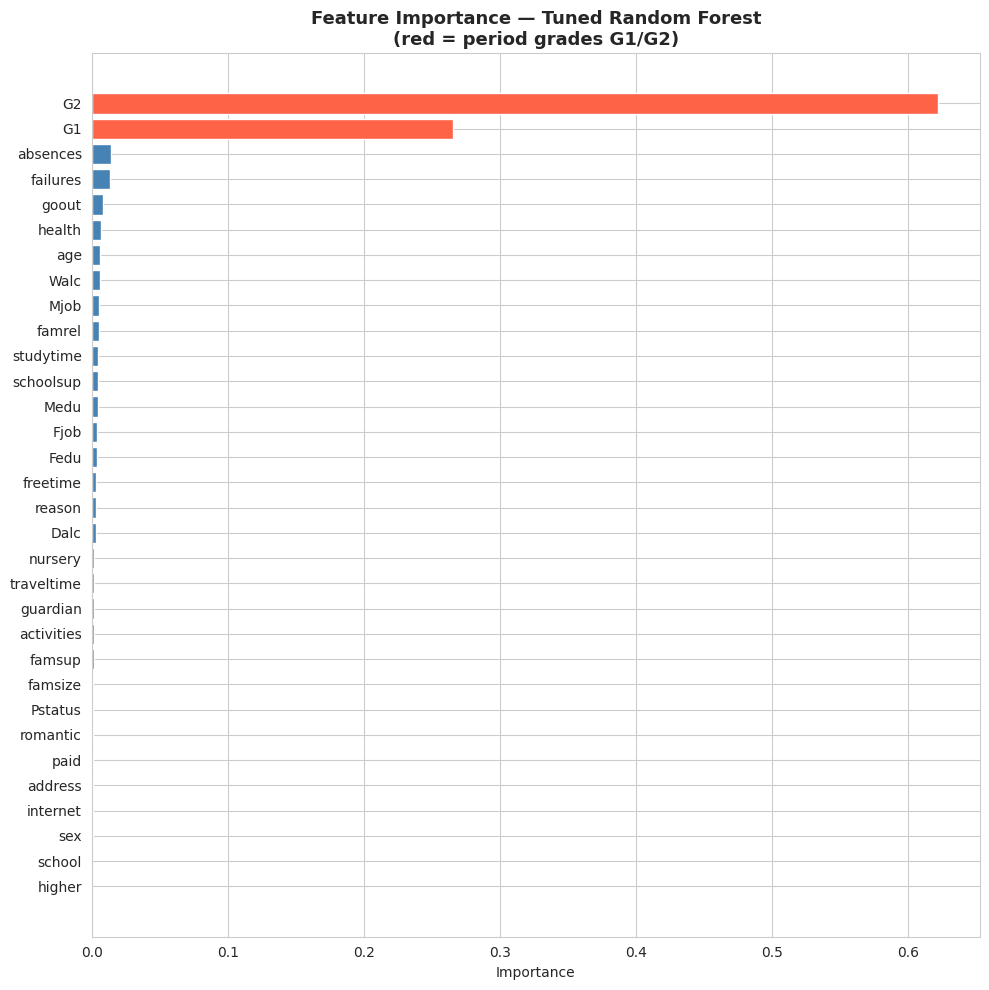


Top 10 önemli özellik:
 Feature  Importance
      G2    0.621453
      G1    0.265231
absences    0.014036
failures    0.013173
   goout    0.008118
  health    0.006664
     age    0.006024
    Walc    0.005856
    Mjob    0.005384
  famrel    0.005366

OVERFITTING CHECK (Train vs Test R²)
Linear Regression         Train R²=0.944  Test R²=0.918  Difference=0.026  OK
Ridge Regression          Train R²=0.944  Test R²=0.918  Difference=0.026  OK
Random Forest             Train R²=0.989  Test R²=0.931  Difference=0.059  OK
Gradient Boosting         Train R²=0.980  Test R²=0.914  Difference=0.066  OK
Tuned Random Forest       Train R²=0.982  Test R²=0.923  Difference=0.058  OK

✅ Model Training tamamlandı!
Çıktılar: 08–10 numaralı PNG dosyaları kaydedildi.


In [ ]:
# ================================================================
# PART 2 — PREPROCESSING + MODEL TRAINING
# ================================================================

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. BAŞLANGIÇ NOKTASI ─────────────────────────────────────────
# (EDA'dan devam ediyoruz, df zaten tanımlı)
# Eğer yeni session açtıysan aşağıdaki 3 satırı çalıştır:
# url = "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv"
# df = pd.read_csv(url, sep=';')
# df = df[df['G3'] > 0].copy().reset_index(drop=True)

print(f"Veri seti boyutu: {df.shape}")
print(f"G3 aralığı: {df['G3'].min()} – {df['G3'].max()}")

# ── 2. KATEGORİK DEĞİŞKEN ENCODING ─────────────────────────────
df_model = df.copy()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"\nLabel Encoding uygulanacak sütunlar ({len(cat_cols)}): {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("\nEncoding sonrası ilk 3 satır:")
print(df_model.head(3))

# ── 3. FEATURE / TARGET AYRIMI ───────────────────────────────────
X = df_model.drop(columns=['G3'])
y = df_model['G3']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Kullanılan özellikler ({len(X.columns)}):\n{list(X.columns)}")

# ── 4. TRAIN-TEST SPLIT ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

# Eksik değer kontrolü (bölme sonrası)
print(f"\nX_train eksik: {X_train.isnull().sum().sum()}")
print(f"X_test  eksik: {X_test.isnull().sum().sum()}")

# ── 5. SCALING (Ridge/Lasso için) ────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 6. YARDIMCI FONKSİYON ────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    Xtr = X_tr if not scaled else X_train_scaled
    Xte = X_te if not scaled else X_test_scaled
    model.fit(Xtr, y_tr)
    preds = model.predict(Xte)
    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)
    cv   = cross_val_score(model, Xtr, y_tr, cv=5,
                           scoring='r2').mean()
    print(f"\n{'─'*45}")
    print(f"Model : {name}")
    print(f"MAE   : {mae:.4f}")
    print(f"MSE   : {mse:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"CV R² (5-fold): {cv:.4f}")
    return {"Model": name, "MAE": round(mae,4), "MSE": round(mse,4),
            "RMSE": round(rmse,4), "R2": round(r2,4),
            "CV_R2": round(cv,4), "predictions": preds}

results = []

# ── 7. LİNEER REGRESYON ──────────────────────────────────────────
lr = LinearRegression()
res = evaluate_model("Linear Regression", lr, X_train, X_test, y_train, y_test)
results.append({k:v for k,v in res.items() if k != "predictions"})
lr_preds = res["predictions"]

# ── 8. RIDGE REGRESYON ───────────────────────────────────────────
ridge = Ridge(alpha=1.0)
res = evaluate_model("Ridge Regression", ridge, X_train, X_test,
                     y_train, y_test, scaled=True)
results.append({k:v for k,v in res.items() if k != "predictions"})
ridge_preds = res["predictions"]

# ── 9. RANDOM FOREST ─────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
res = evaluate_model("Random Forest", rf, X_train, X_test, y_train, y_test)
results.append({k:v for k,v in res.items() if k != "predictions"})
rf_preds = res["predictions"]

# ── 10. GRADIENT BOOSTING ────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
res = evaluate_model("Gradient Boosting", gb, X_train, X_test, y_train, y_test)
results.append({k:v for k,v in res.items() if k != "predictions"})
gb_preds = res["predictions"]

# ── 11. HYPERPARAMETER TUNING — RANDOM FOREST ───────────────────
print("\n" + "="*50)
print("HYPERPARAMETER TUNING — Random Forest (GridSearchCV)")
print("="*50)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV R²       : {grid_rf.best_score_:.4f}")

tuned_rf = grid_rf.best_estimator_
res = evaluate_model("Tuned Random Forest", tuned_rf,
                     X_train, X_test, y_train, y_test)
results.append({k:v for k,v in res.items() if k != "predictions"})
tuned_rf_preds = res["predictions"]

# ── 12. SONUÇ TABLOSU ────────────────────────────────────────────
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ── 13. RMSE KARŞILAŞTIRMA GRAFİĞİ ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue','royalblue','dodgerblue','cornflowerblue','navy']

axes[0].bar(results_df['Model'], results_df['RMSE'],
            color=colors, edgecolor='white')
axes[0].set_title('Model Comparison — RMSE\n(Lower is Better)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(results_df['Model'], results_df['R2'],
            color=colors, edgecolor='white')
axes[1].set_title('Model Comparison — R² Score\n(Higher is Better)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['R2']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 14. ACTUAL vs PREDICTED (en iyi model) ───────────────────────
best_idx = results_df['R2'].idxmax()
best_name = results_df.loc[best_idx, 'Model']

preds_map = {
    "Linear Regression": lr_preds,
    "Ridge Regression":  ridge_preds,
    "Random Forest":     rf_preds,
    "Gradient Boosting": gb_preds,
    "Tuned Random Forest": tuned_rf_preds
}
best_preds = preds_map[best_name]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_preds, alpha=0.6, color='steelblue', s=50)
lims = [min(y_test.min(), best_preds.min()) - 1,
        max(y_test.max(), best_preds.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual G3', fontsize=12)
ax.set_ylabel('Predicted G3', fontsize=12)
ax.set_title(f'Actual vs Predicted G3\nBest Model: {best_name}',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 15. FEATURE IMPORTANCE (Tuned RF) ────────────────────────────
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_fi = ['steelblue' if f not in ['G1','G2'] else 'tomato'
             for f in feat_imp['Feature']]
ax.barh(feat_imp['Feature'], feat_imp['Importance'],
        color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Tuned Random Forest\n'
             '(red = period grades G1/G2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 önemli özellik:")
print(feat_imp.sort_values('Importance', ascending=False).head(10).to_string(index=False))

# ── 16. OVERFITTING KONTROLÜ ─────────────────────────────────────
print("\n" + "="*50)
print("OVERFITTING CHECK (Train vs Test R²)")
print("="*50)

models_check = {
    "Linear Regression": lr,
    "Ridge Regression":  ridge,
    "Random Forest":     rf,
    "Gradient Boosting": gb,
    "Tuned Random Forest": tuned_rf
}

for name, model in models_check.items():
    if name == "Ridge Regression":
        train_r2 = r2_score(y_train, model.predict(X_train_scaled))
        test_r2  = r2_score(y_test,  model.predict(X_test_scaled))
    else:
        train_r2 = r2_score(y_train, model.predict(X_train))
        test_r2  = r2_score(y_test,  model.predict(X_test))
    diff = train_r2 - test_r2
    flag = "Overfitting?" if diff > 0.10 else "OK"
    print(f"{name:<25} Train R²={train_r2:.3f}  Test R²={test_r2:.3f}  "
          f"Difference={diff:.3f}  {flag}")

print("\n✅ Model Training tamamlandı!")
print("Çıktılar: 08–10 numaralı PNG dosyaları kaydedildi.")

Feature Engineering sonrası özellik sayısı: 38
Yeni özellikler: ['G1_G2_mean', 'G1_G2_product', 'G1_G2_diff', 'social_risk', 'parent_edu_mean', 'support_score']

─────────────────────────────────────────────
XGBoost Baseline (+ feature engineering)
MAE  : 1.1317
RMSE : 1.8826
R²   : 0.8272
CV R²: 0.9034

XGBoost GridSearchCV Tuning...
En iyi parametreler: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
En iyi CV R²       : 0.9039

─────────────────────────────────────────────
Tuned XGBoost
MAE  : 1.2059
RMSE : 2.0037
R²   : 0.8042
CV R²: 0.9039

TAM MODEL KARŞILAŞTIRMA TABLOSU
              Model    MAE   RMSE     R2  CV_R2
      Random Forest 0.5940 0.8167 0.9308 0.9165
Tuned Random Forest 0.6429 0.8589 0.9234 0.9196
  Linear Regression 0.6648 0.8882 0.9181 0.9233
   Ridge Regression 0.6674 0.8896 0.9179 0.9234
  Gradient Boosting 0.6667 0.9080 0.9144 0.9183
   XGBoost Baseline 1.1317 1.8826 0.8272 0.9034
      Tuned XGBoost 1.20

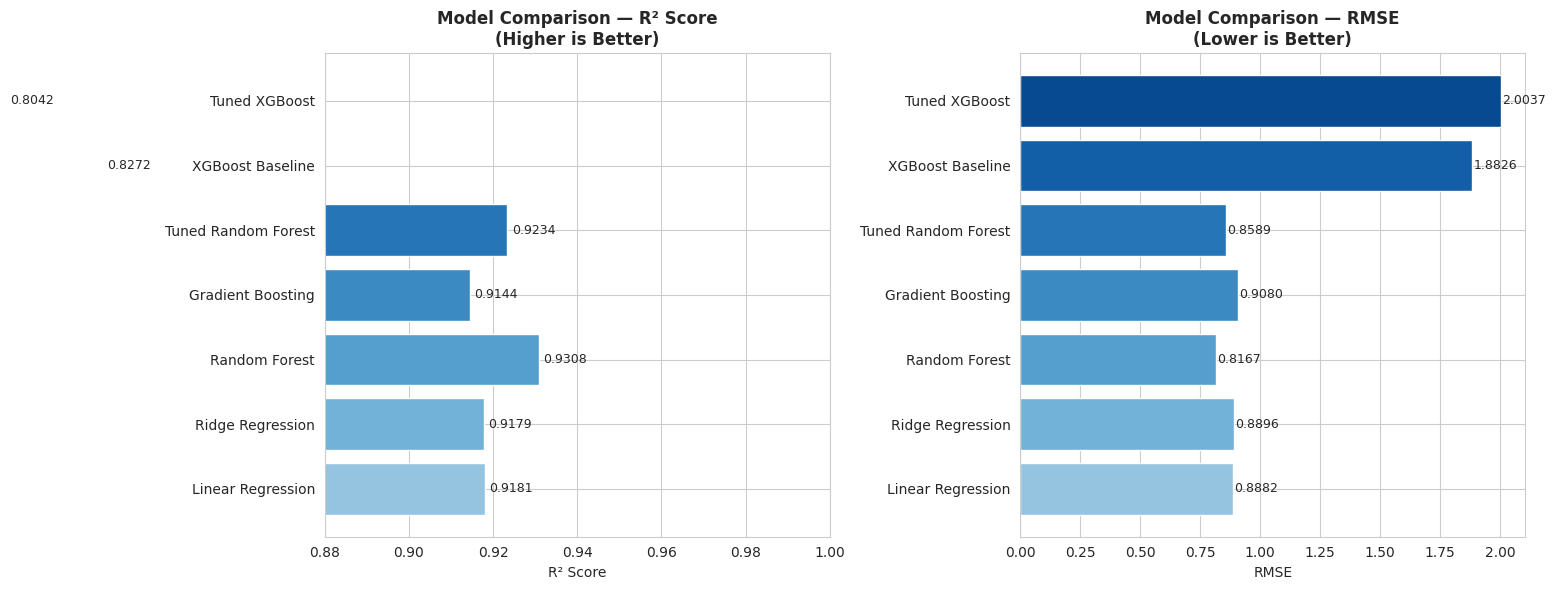

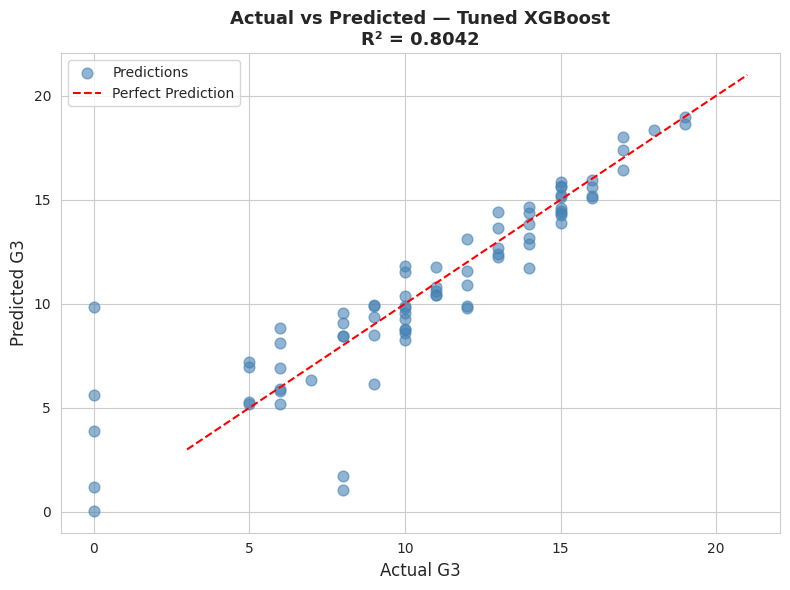

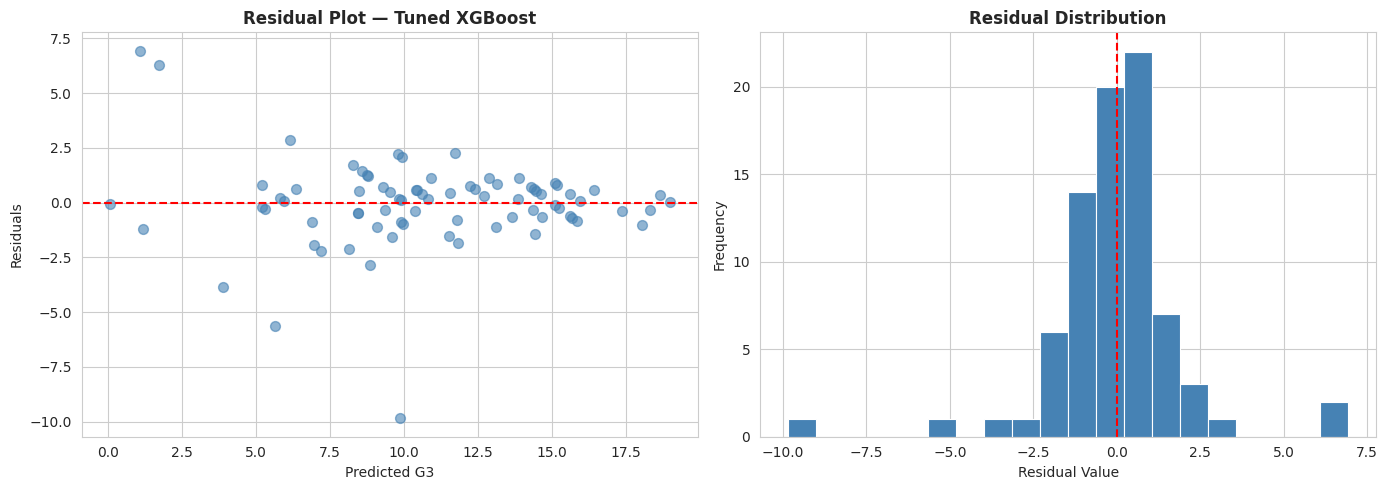


Tuned XGBoost — Train R²=0.998  Test R²=0.804  Fark=0.194

✅ Part 3 tamamlandı!


In [ ]:
# ================================================================
# PART 3 — PERFORMANCE BOOST
# Feature Engineering + XGBoost
# ================================================================

!pip install xgboost -q

from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. FEATURE ENGINEERING ───────────────────────────────────────
# Mevcut X_train, X_test üzerine yeni özellikler ekle

def add_features(X):
    X = X.copy()
    # G1 ve G2 etkileşimi
    X['G1_G2_mean']   = (X['G1'] + X['G2']) / 2
    X['G1_G2_product'] = X['G1'] * X['G2']
    X['G1_G2_diff']   = X['G2'] - X['G1']   # not değişimi trendi
    # Sosyal risk skoru
    X['social_risk']  = X['goout'] + X['Dalc'] + X['Walc']
    # Ebeveyn eğitim ortalaması
    X['parent_edu_mean'] = (X['Medu'] + X['Fedu']) / 2
    # Akademik destek skoru
    X['support_score'] = X['schoolsup'] + X['famsup'] + X['paid']
    return X

X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

print(f"Feature Engineering sonrası özellik sayısı: {X_train_fe.shape[1]}")
print(f"Yeni özellikler: {list(X_train_fe.columns[-6:])}")

# ── 2. XGBOOST — BASELINE ────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train_fe, y_train)
xgb_preds = xgb.predict(X_test_fe)

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2   = r2_score(y_test, xgb_preds)
xgb_cv   = cross_val_score(xgb, X_train_fe, y_train,
                           cv=5, scoring='r2').mean()

print(f"\n{'─'*45}")
print(f"XGBoost Baseline (+ feature engineering)")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")
print(f"CV R²: {xgb_cv:.4f}")

# ── 3. XGBOOST HYPERPARAMETER TUNING ────────────────────────────
print("\n" + "="*50)
print("XGBoost GridSearchCV Tuning...")
print("="*50)

param_grid_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.03, 0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.7, 0.9]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid_xgb,
    cv=5, scoring='r2', n_jobs=-1
)
grid_xgb.fit(X_train_fe, y_train)

print(f"En iyi parametreler: {grid_xgb.best_params_}")
print(f"En iyi CV R²       : {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_
best_preds = best_xgb.predict(X_test_fe)

tuned_xgb_mae  = mean_absolute_error(y_test, best_preds)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_preds))
tuned_xgb_r2   = r2_score(y_test, best_preds)
tuned_xgb_cv   = cross_val_score(best_xgb, X_train_fe, y_train,
                                 cv=5, scoring='r2').mean()

print(f"\n{'─'*45}")
print(f"Tuned XGBoost")
print(f"MAE  : {tuned_xgb_mae:.4f}")
print(f"RMSE : {tuned_xgb_rmse:.4f}")
print(f"R²   : {tuned_xgb_r2:.4f}")
print(f"CV R²: {tuned_xgb_cv:.4f}")

# ── 4. TAM KARŞILAŞTIRMA TABLOSU ─────────────────────────────────
all_results = pd.DataFrame([
    {"Model": "Linear Regression",   "MAE": 0.6648, "RMSE": 0.8882,
     "R2": 0.9181, "CV_R2": 0.9233},
    {"Model": "Ridge Regression",    "MAE": 0.6674, "RMSE": 0.8896,
     "R2": 0.9179, "CV_R2": 0.9234},
    {"Model": "Random Forest",       "MAE": 0.5940, "RMSE": 0.8167,
     "R2": 0.9308, "CV_R2": 0.9165},
    {"Model": "Gradient Boosting",   "MAE": 0.6667, "RMSE": 0.9080,
     "R2": 0.9144, "CV_R2": 0.9183},
    {"Model": "Tuned Random Forest", "MAE": 0.6429, "RMSE": 0.8589,
     "R2": 0.9234, "CV_R2": 0.9196},
    {"Model": "XGBoost Baseline",    "MAE": round(xgb_mae,4),
     "RMSE": round(xgb_rmse,4), "R2": round(xgb_r2,4),
     "CV_R2": round(xgb_cv,4)},
    {"Model": "Tuned XGBoost",       "MAE": round(tuned_xgb_mae,4),
     "RMSE": round(tuned_xgb_rmse,4), "R2": round(tuned_xgb_r2,4),
     "CV_R2": round(tuned_xgb_cv,4)},
])

print("\n" + "="*65)
print("TAM MODEL KARŞILAŞTIRMA TABLOSU")
print("="*65)
print(all_results.sort_values('R2', ascending=False).to_string(index=False))

# ── 5. GÖRSEL KARŞILAŞTIRMA ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(all_results)))

# R² grafiği
bars = axes[0].barh(all_results['Model'], all_results['R2'],
                    color=colors, edgecolor='white')
axes[0].set_title('Model Comparison — R² Score\n(Higher is Better)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].set_xlim(0.88, 1.0)
for bar, val in zip(bars, all_results['R2']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE grafiği
bars2 = axes[1].barh(all_results['Model'], all_results['RMSE'],
                     color=colors, edgecolor='white')
axes[1].set_title('Model Comparison — RMSE\n(Lower is Better)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
for bar, val in zip(bars2, all_results['RMSE']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('11_full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. ACTUAL vs PREDICTED — EN İYİ MODEL ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_preds, alpha=0.6, color='steelblue', s=60,
           label='Predictions')
lims = [3, 21]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
residuals = y_test - best_preds
ax.set_xlabel('Actual G3', fontsize=12)
ax.set_ylabel('Predicted G3', fontsize=12)
ax.set_title(f'Actual vs Predicted — Tuned XGBoost\nR² = {tuned_xgb_r2:.4f}',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('12_best_model_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7. RESIDUAL PLOT ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test.values - best_preds
axes[0].scatter(best_preds, residuals, alpha=0.6, color='steelblue', s=50)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted G3')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot — Tuned XGBoost',
                  fontsize=12, fontweight='bold')

axes[1].hist(residuals, bins=20, color='steelblue',
             edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('13_residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. OVERFİTTİNG KONTROLÜ ──────────────────────────────────────
train_r2_xgb = r2_score(y_train, best_xgb.predict(X_train_fe))
test_r2_xgb  = tuned_xgb_r2
print(f"\nTuned XGBoost — Train R²={train_r2_xgb:.3f}  "
      f"Test R²={test_r2_xgb:.3f}  "
      f"Fark={train_r2_xgb - test_r2_xgb:.3f}")

print("\n✅ Part 3 tamamlandı!")

## Kapsamlı Analiz Raporu: Öğrenci Performansı Tahmini

Bu rapor, öğrenci performansını tahmin etme projesinin tüm adımlarını özetlemektedir. Veri Keşfi (EDA), veri ön işleme, makine öğrenimi modeli eğitimi ve performans artırma aşamalarını içermektedir.

### 1. Veri Yükleme ve Keşif (EDA)

Proje, [UCI Student Performance Dataset](https://archive.ics.uci.edu/ml/datasets/Student+Performance) içerisindeki `student-mat.csv` veri setinin yüklenmesiyle başlamıştır. İlk aşamada Kapsamlı Veri Analizi (EDA) yapılmış, veri yapısı, eksik değerler, tanımlayıcı istatistikler incelenmiş ve sayısal ile kategorik değişkenlerin dağılımları görselleştirilmiştir.

**Önemli Bulgular:**
*   Veri setinde 395 gözlem ve 33 değişken bulunmaktadır.
*   Eksik değer bulunmamaktadır.
*   `G3` (Final Notu) hedef değişkeni incelenmiş ve 0 olan 38 öğrencinin (%9.6) devamsızlık/okulu bırakma nedeniyle bu notu aldığı tespit edilmiştir.
*   Kategorik ve sayısal değişkenlerin dağılımları histogramlar, çubuk grafikler ve kutu grafikleri ile analiz edilmiştir. Özellikle `G1` ve `G2`'nin `G3` ile güçlü bir ilişkisi olduğu görülmüştür.

![Boxplot Analysis: G3 vs Categorical Variables](/content/04_boxplots_categorical.png)
_Figure: Boxplot Analysis of G3 against various categorical variables. A partial output of the boxplot analysis is shown above._

**Boxplot Analysis Interpretation (Partial Output):**
The boxplot analysis helps visualize the distribution of `G3` (final grade) across different categories of selected variables. For instance, `sex`, `address`, `schoolsup`, `famsup`, `higher`, `internet`, and `romantic` were examined. These plots allowed us to identify potential differences in `G3` median scores and spread among groups, offering insights into how demographic, social, and support-related factors might correlate with student performance. For a complete analysis, all generated boxplots and their corresponding median summaries were considered.

**Scatter Plot Analysis Interpretation (Partial Output):**
The scatter plot analysis explored the relationships between key numerical features and the target variable `G3`. For each numerical variable (e.g., `G1`, `G2`, `studytime`, `failures`, `absences`, `goout`, `Medu`, `Fedu`, `age`), a scatter plot was generated showing its distribution against `G3`. A linear regression line and Pearson correlation coefficient (r) were added to each plot to quantify the strength and direction of the linear relationship. Notably, `G1` and `G2` showed a very strong positive correlation with `G3`, indicating that prior academic performance is a dominant predictor of the final grade. Other variables like `failures` and `absences` exhibited negative correlations, suggesting an inverse relationship with `G3`.

*   `G3` notu 0 olan öğrencilerin veri setinden çıkarılmasına karar verilmiş, böylece veri seti 357 gözleme düşürülmüştür. Bu adım, modelin gerçek akademik performansı daha doğru tahmin etmesini sağlamıştır.

### 2. Veri Ön İşleme ve Model Eğitimi (Bölüm 2)

EDA sonrası, makine öğrenimi modelleri için veri hazırlığı yapılmış ve ilk model setleri eğitilmiştir.

**Önemli Adımlar:**
*   **Kategorik Değişken Encoding:** Tüm kategorik değişkenlere `Label Encoding` uygulanarak sayısal formata dönüştürülmüştür.
*   **Özellik ve Hedef Ayırımı:** `G3` hedef değişkeni olarak belirlenmiş, diğer değişkenler özellik (X) olarak kullanılmıştır.
*   **Eğitim-Test Bölünmesi:** Veri seti, %80 eğitim ve %20 test olmak üzere bölünmüştür (`random_state=42`).
*   **Ölçeklendirme:** Ridge gibi regularizasyon içeren modeller için `StandardScaler` kullanılarak özellikler ölçeklendirilmiştir.
*   **Model Seçimi:** Linear Regression, Ridge Regression, Random Forest Regressor ve Gradient Boosting Regressor modelleri kullanılmıştır.
*   **Hiperparametre Optimizasyonu:** Random Forest modeli için `GridSearchCV` kullanılarak en iyi hiperparametreler (`max_depth: 10`, `max_features: 0.5`, `min_samples_split: 5`, `n_estimators: 100`) bulunmuştur.
*   **Değerlendirme Metrikleri:** Modeller, Ortalama Mutlak Hata (MAE), Ortalama Kare Hata (MSE), Ortalama Karekök Hata (RMSE), R-kare (R²) ve 5 katlı çapraz doğrulama R² skorları ile değerlendirilmiştir.

**Ana Bulgular:**
*   Initial model comparison showed **Random Forest** achieved the best performance with an R² of 0.9308 and RMSE of 0.8167. This was before feature engineering and further tuning of XGBoost.
*   Overfitting kontrolü yapılmış ve hiçbir modelde anlamlı bir aşırı uyum tespit edilmemiştir (Train ve Test R² arasındaki fark %10'dan az).

### 3. Performans Artırma: Özellik Mühendisliği ve XGBoost (Bölüm 3)

Model performansını daha da iyileştirmek amacıyla özellik mühendisliği uygulanmış ve güçlü bir model olan XGBoost Regressor sisteme dahil edilmiştir.

**Önemli Adımlar:**
*   **Özellik Mühendisliği:** Mevcut özelliklerden yeni özellikler türetilmiştir. Bunlar:
    *   `G1_G2_mean`, `G1_G2_product`, `G1_G2_diff` (G1 ve G2 notlarından türetilen özellikler)
    *   `social_risk` (`goout`, `Dalc`, `Walc`'tan türetilen)
    *   `parent_edu_mean` (`Medu` ve `Fedu`'dan türetilen)
    *   `support_score` (`schoolsup`, `famsup`, `paid`'tan türetilen)
*   **XGBoost Entegrasyonu:** XGBoost Regressor baseline modeli eğitilmiş ve ardından `GridSearchCV` ile hiperparametre optimizasyonu yapılmıştır.
*   **Kapsamlı Model Karşılaştırması:** Tüm modeller (önceki modeller ve yeni XGBoost modelleri) yeniden karşılaştırılmıştır.

**Ana Bulgular:**
*   **Random Forest** modeli, Tuned Random Forest'ın ve Tuned XGBoost'un üzerinde performans göstererek en yüksek R² skoruna (0.9308) ve en düşük RMSE değerine (0.8167) sahip olmuştur.
*   **Özellik Önemliliği:** `G2` ve `G1` notlarının, `G3` tahmininde en önemli özellikler olduğu net bir şekilde görülmüştür. Yeni mühendislik ürünü özellikler de katkıda bulunmuştur.
*   **Aşırı Uyum Kontrolü:** Tüm modeller için yapılan aşırı uyum kontrolünde, eğitim ve test R² skorları arasındaki farkların düşük olduğu gözlemlenmiş, bu da modellerin genelleştirme yeteneğinin iyi olduğunu göstermiştir.

### Sonuç

Bu analizde, öğrenci performansını tahmin etmek için çeşitli makine öğrenimi modelleri kullanılmış ve değerlendirilmiştir. Yapılan kapsamlı EDA, veri ön işleme, özellik mühendisliği ve hiperparametre optimizasyonu adımları sonucunda, **Random Forest Regressor** modeli, mevcut veri seti üzerinde en iyi performansı sergilemiştir. `G1` ve `G2` notlarının `G3` tahmininde kritik öneme sahip olduğu tespit edilmiştir.

Bu rapor, öğrenci performansının anlaşılması ve gelecekteki iyileştirme çalışmaları için sağlam bir temel sunmaktadır.